In [1]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from utils.cleaning import mapping, pipeline_limpieza_completa
from utils.plots import pipeline_figuras_h01

In [2]:
df_raw = pd.read_csv('../data/raw/openfoodfacts_nutrition_final_2025-12-10.csv')
df_raw.info()

df_meat_production = pd.read_csv('../data/raw/FAOSTAT_meat_prod_2024.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                9804 non-null   int64  
 1   product_name        9566 non-null   object 
 2   brands              9430 non-null   object 
 3   countries           9802 non-null   object 
 4   quantity            8816 non-null   object 
 5   categories          9683 non-null   object 
 6   labels              7552 non-null   object 
 7   nutriscore_grade    9801 non-null   object 
 8   ecoscore_grade      9802 non-null   object 
 9   nova_group          8959 non-null   float64
 10  ingredients_text    9406 non-null   object 
 11  energy-kcal_100g    9280 non-null   float64
 12  fat_100g            9309 non-null   float64
 13  saturated-fat_100g  9140 non-null   float64
 14  carbohydrates_100g  9284 non-null   float64
 15  sugars_100g         9168 non-null   float64
 16  fiber_

## ⚙️ Motor de Limpieza e Integridad Nutricional

### Se ejecuta el pipeline `pipeline_limpieza_completa` para transformar el dataset crudo en una matriz de auditoría técnica.

### Principales transformaciones aplicadas:

### 🌍 Filtro Geográfico: Unificación de mercados internacionales (ES, FR, DE, UK, etc.).

### 🥗 Taxonomía Experta: Clasificación en 12 categorías maestras con lógica de "vetos" (ej. evitar que una leche se clasifique como refresco).

### 🏢 Mapeo Corporativo: Agrupación de marcas bajo su matriz (Nestlé, Danone, Hacendado, Lidl, etc.) eliminando ruido tipográfico.

### 🧪 Extracción de Atributos: Detección de sellos Bio, presencia de aceite de palma, azúcares añadidos y conteo de aditivos.

### ⚖️ Criterio Biológico: Imputación de fibra condicionada (0 en origen animal) para garantizar la integridad estadística.

### Estado del Output: Dataset de alta fidelidad con 0% de valores nulos en variables críticas, listo para análisis exploratorio (EDA).

In [3]:
from utils.cleaning import mapping, pipeline_limpieza_completa
df_audit = pipeline_limpieza_completa(df_raw, mapping)
df_audit.info()

Log: Filtro de países aplicado. Registros resultantes: 9738
Log: Refinamiento granular finalizado.
Log: Categorías residuales eliminadas. (Descartados: 583)
Log: Clasificación de marcas completada. Cobertura: 73.51%
Log: Clasificación Bio completada. Cobertura: 11.31%
Log: Extracción de ingredientes y aditivos finalizada.
Log: Imputación de fibra completada.
Log: Integridad del dataset optimizada. Tamaño final: 7686
✅ Pipeline finalizado con éxito.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7686 entries, 0 to 7685
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                7686 non-null   int64  
 1   product_name        7686 non-null   object 
 2   brands              7686 non-null   object 
 3   countries           7686 non-null   object 
 4   categories          7686 non-null   object 
 5   labels              7686 non-null   object 
 6   nutriscore_grade    7686 non-null   object 

## H01: La Paradoja del Algoritmo (Nutri-Score vs. NOVA)

### En este primer bloque se analiza la correlación entre la calidad nutricional de los productos y su grado de procesamiento. Mientras que el Nutri-Score se centra en la composición química (macronutrientes), la clasificación NOVA evalúa la naturaleza del procesamiento industrial.

### ¿Es posible tener una buena nota nutricional en un producto ultraprocesado?

### Para responder a esto, ejecutamos tres niveles de análisis visual:

### Cruce de Variables: Identificación de la densidad de productos en la "zona de paradoja" (Nutri-Score A/B + NOVA 4).

### Ingeniería Inversa: Modelado matemático mediante regresión para entender qué nutrientes "compran" una mejor nota en cada categoría.

### Contraste Crítico: Comparativa directa de un alimento mínimamente procesado (Aceite de Oliva) frente a un producto de alta ingeniería alimentaria (Cereales de desayuno).

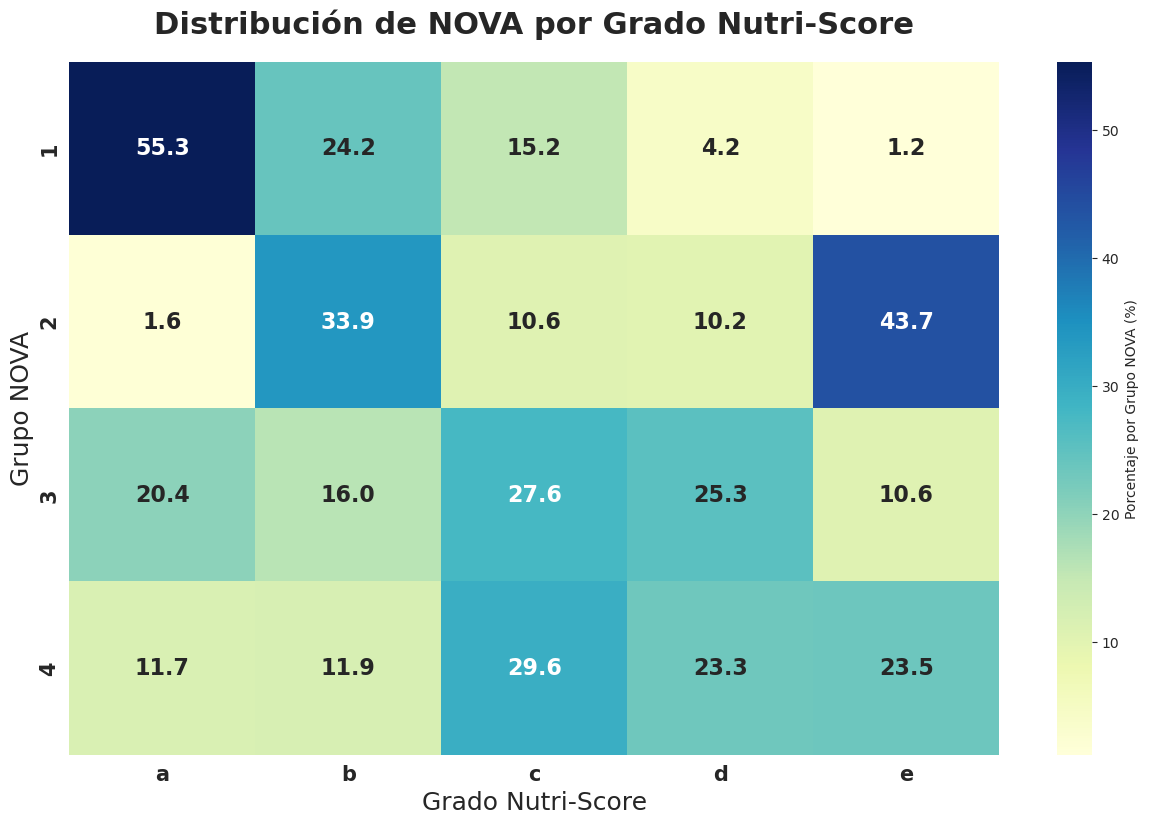

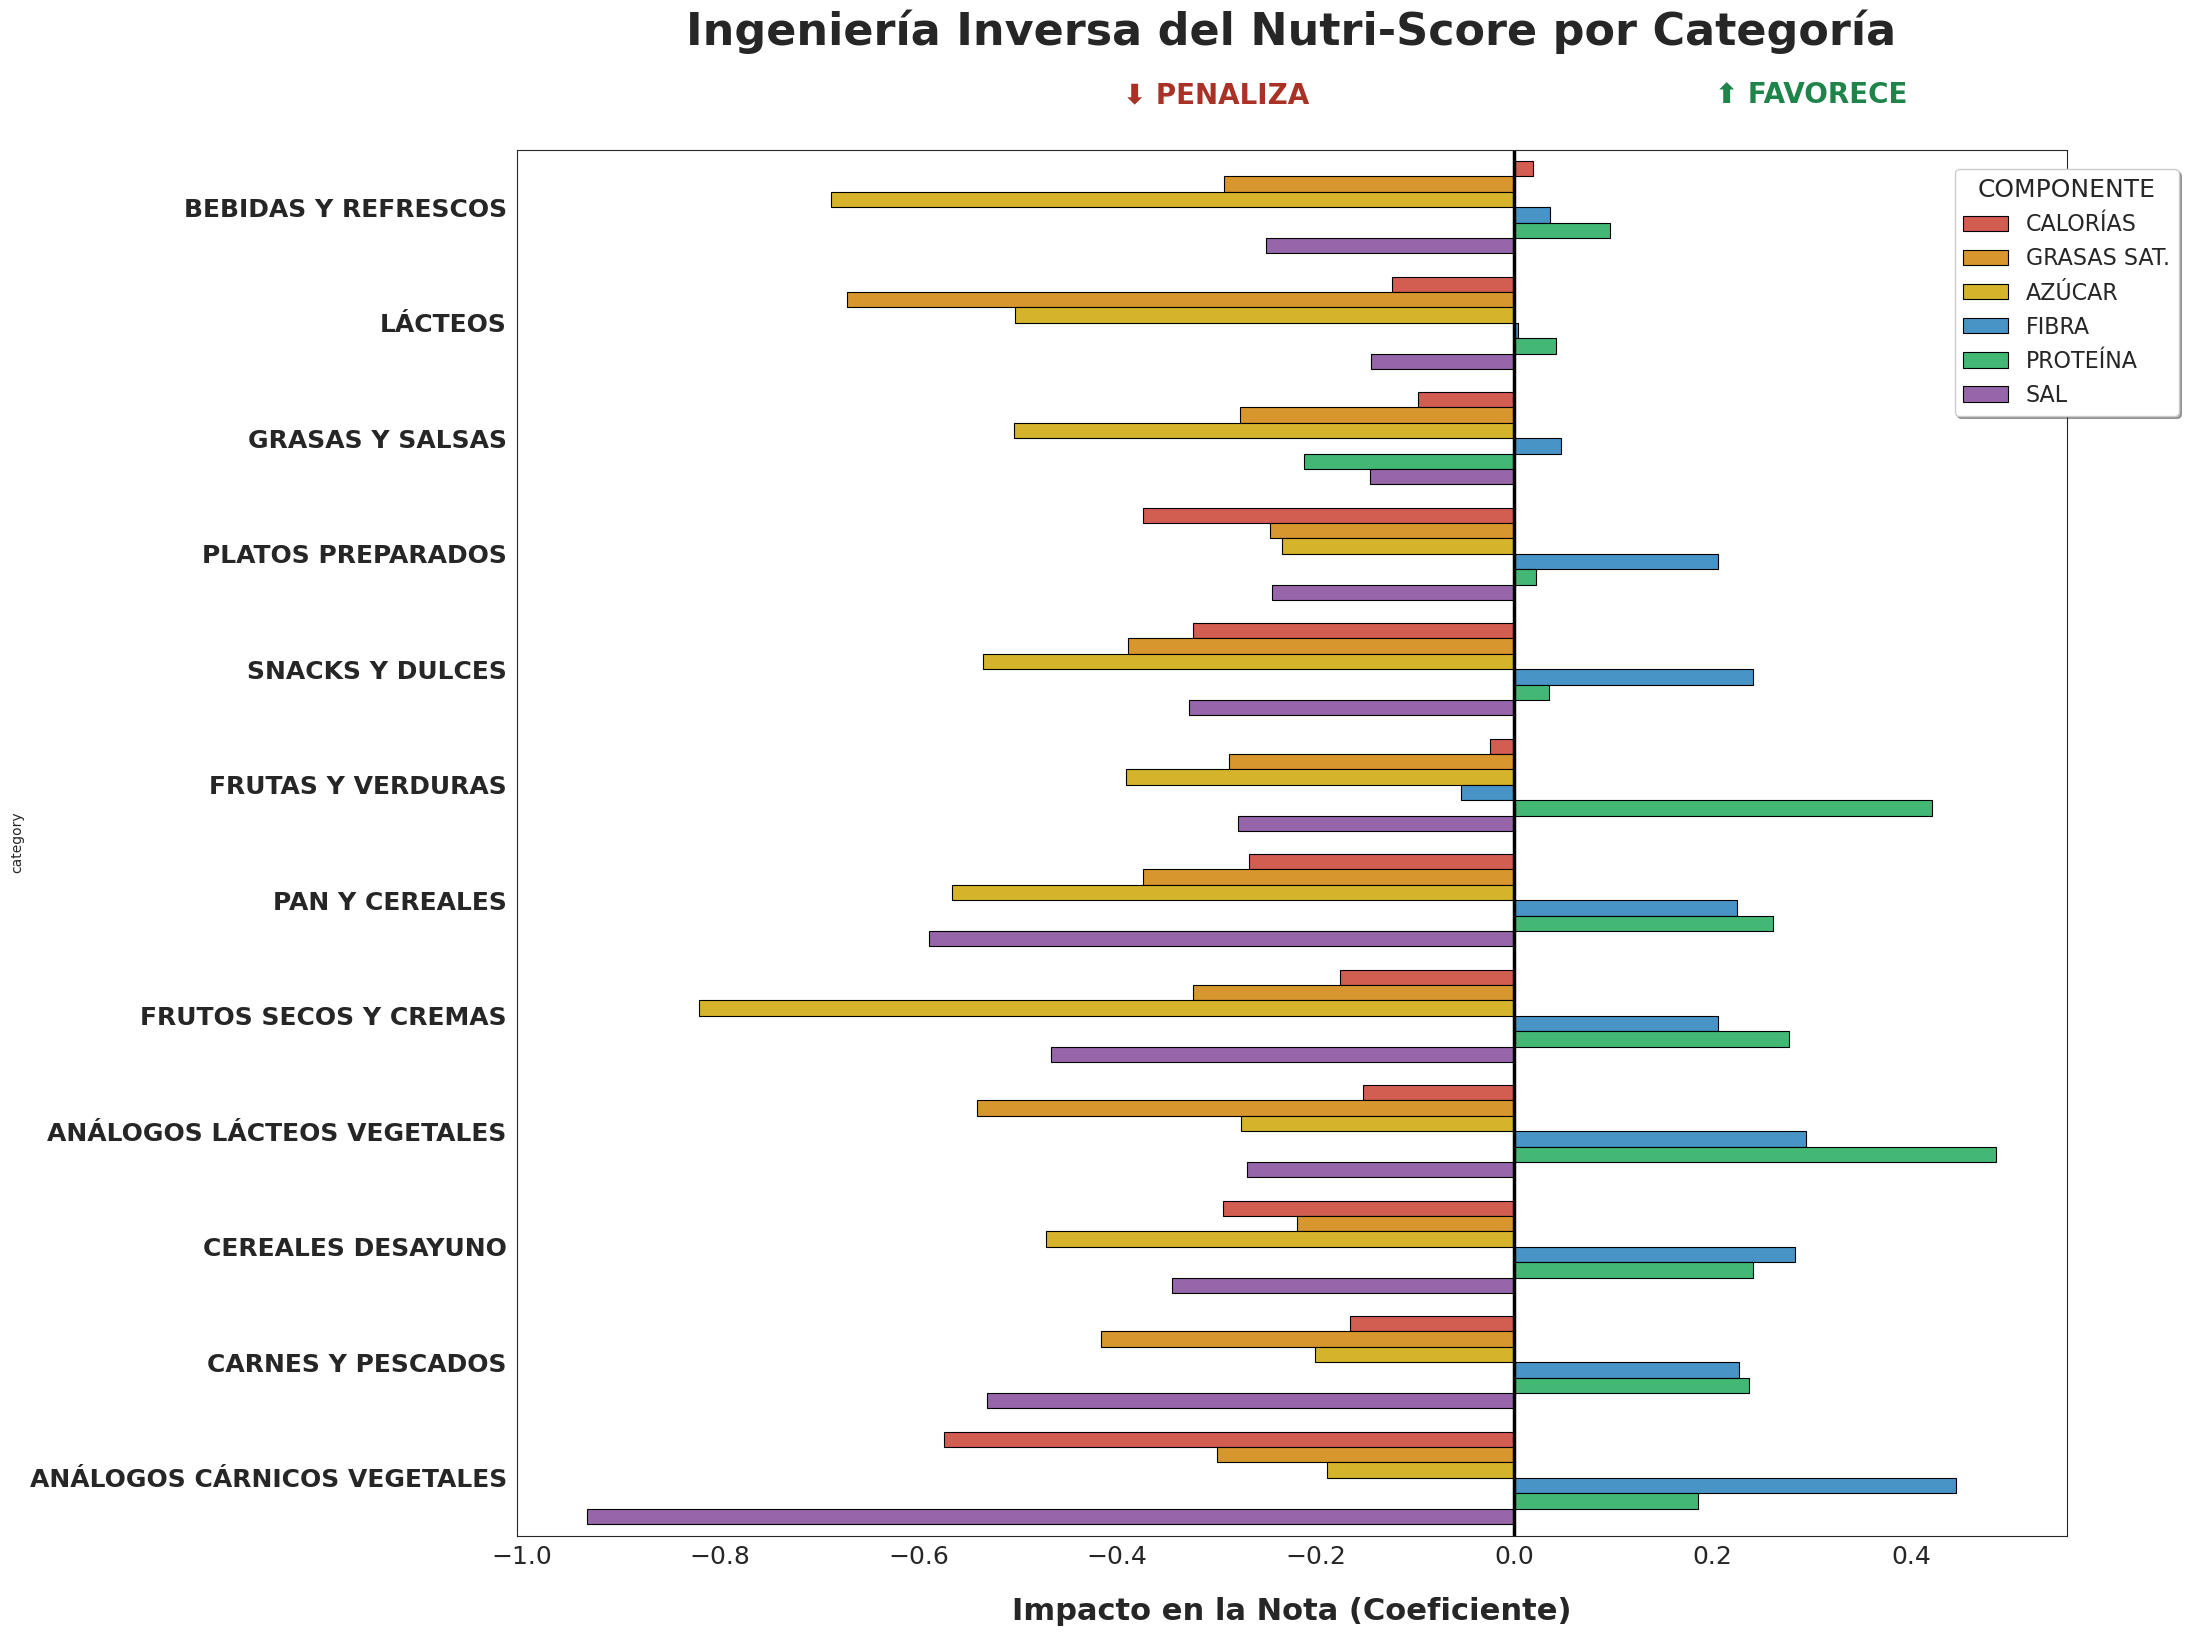

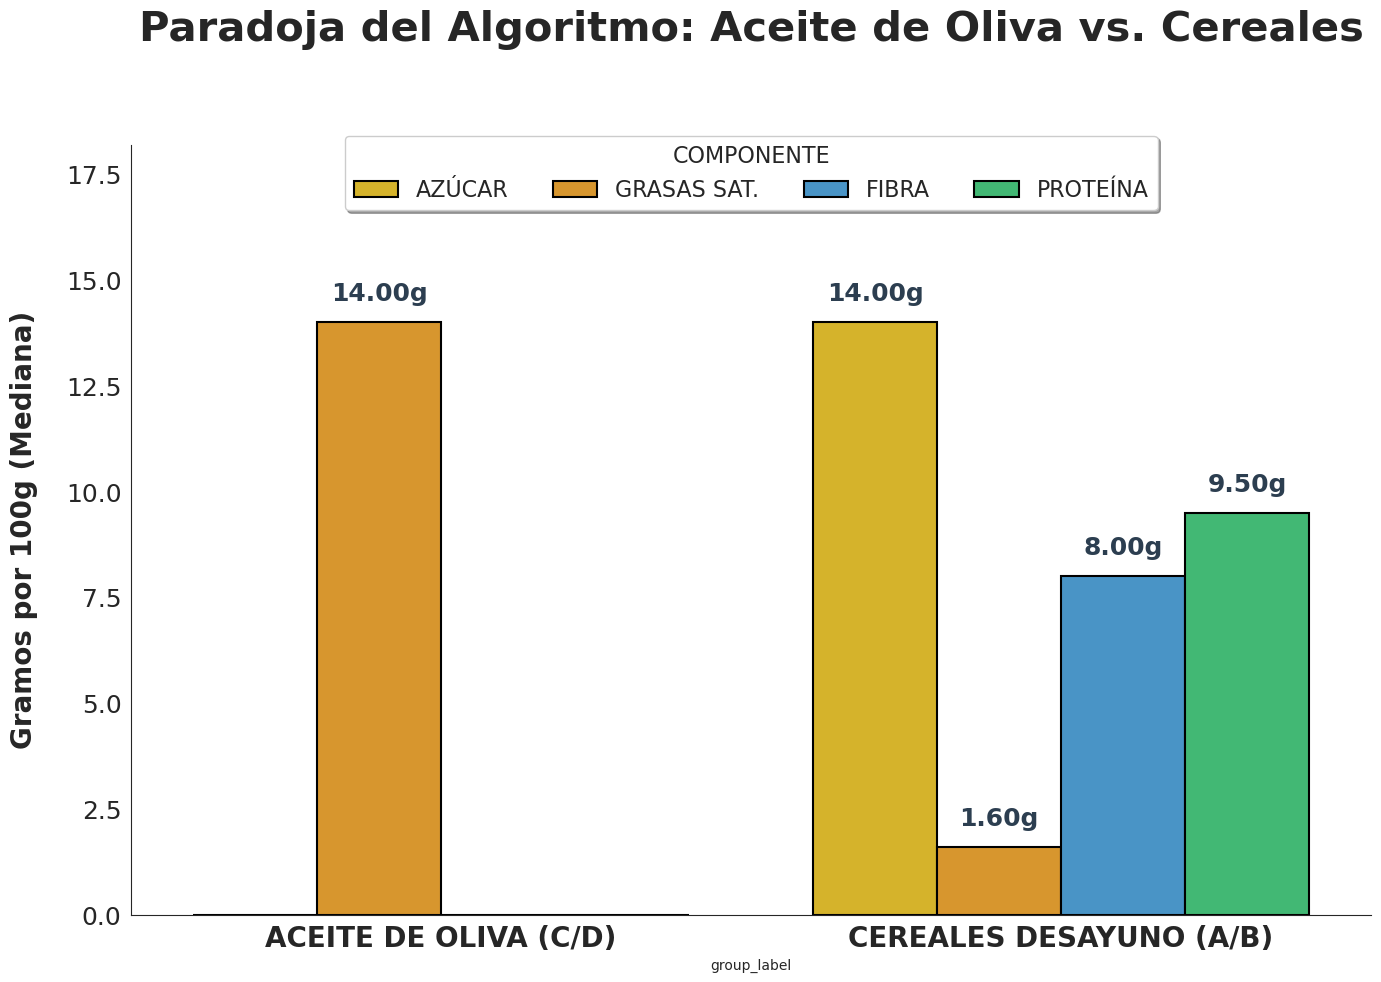

✅ Análisis H01 completado.


In [4]:
pipeline_figuras_h01(df_audit)

## H02: El Sello "Bio" a Examen (¿Marketing o Salud?)

### En este bloque analizamos si la certificación ecológica conlleva realmente una mejora en la calidad nutricional y una reducción en el grado de procesamiento, o si se utiliza como una herramienta de posicionamiento premium sin beneficios claros en la composición.

### ¿Es el sello "Bio" una garantía de alimento menos procesado y más nutritivo?

### Para responder a esto, ejecutamos tres niveles de análisis visual:

### Penetración de Mercado: Mapeo de la presencia del segmento orgánico en las diferentes categorías del dataset.

### Triangulación de Indicadores: Comparativa directa de la distribución de `Eco-Score`, `Nutri-Score` y `NOVA` entre productos Bio y Convencionales.

### Carga Química Aditiva: Heatmap de la media de aditivos por categoría para verificar si el sello ecológico cumple con la promesa de una etiqueta más limpia (Clean Label).

📊 Iniciando Análisis del Segmento Bio (H02)...


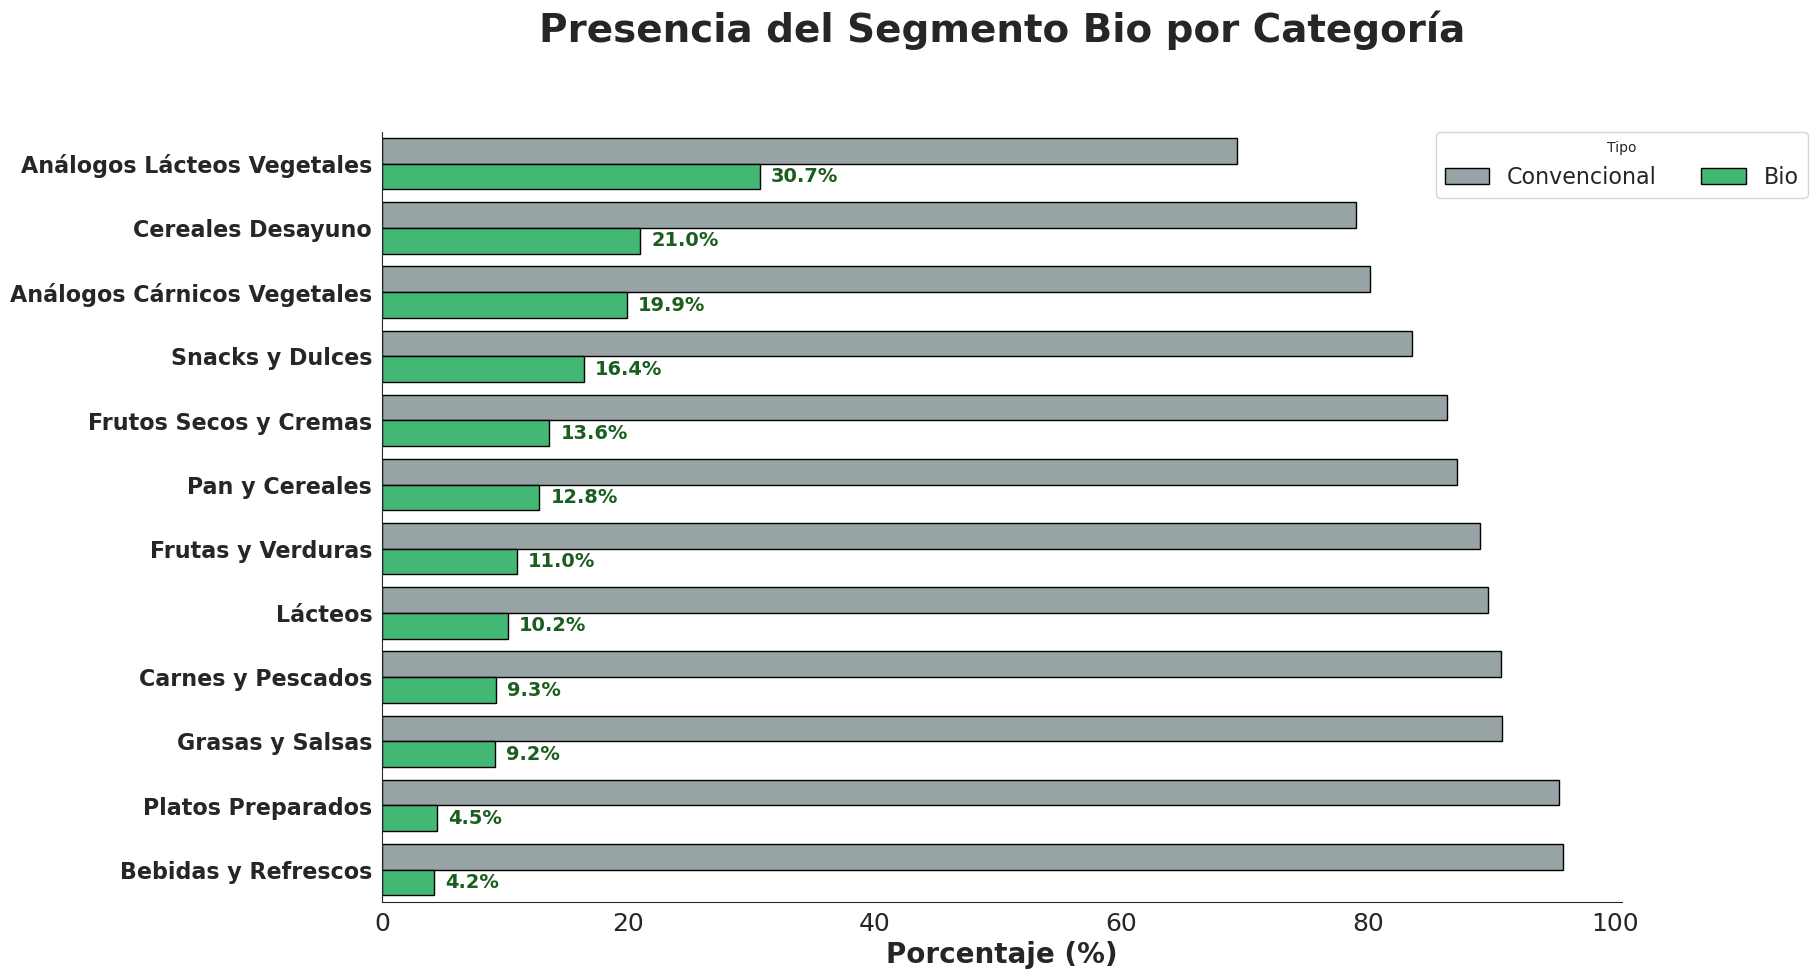

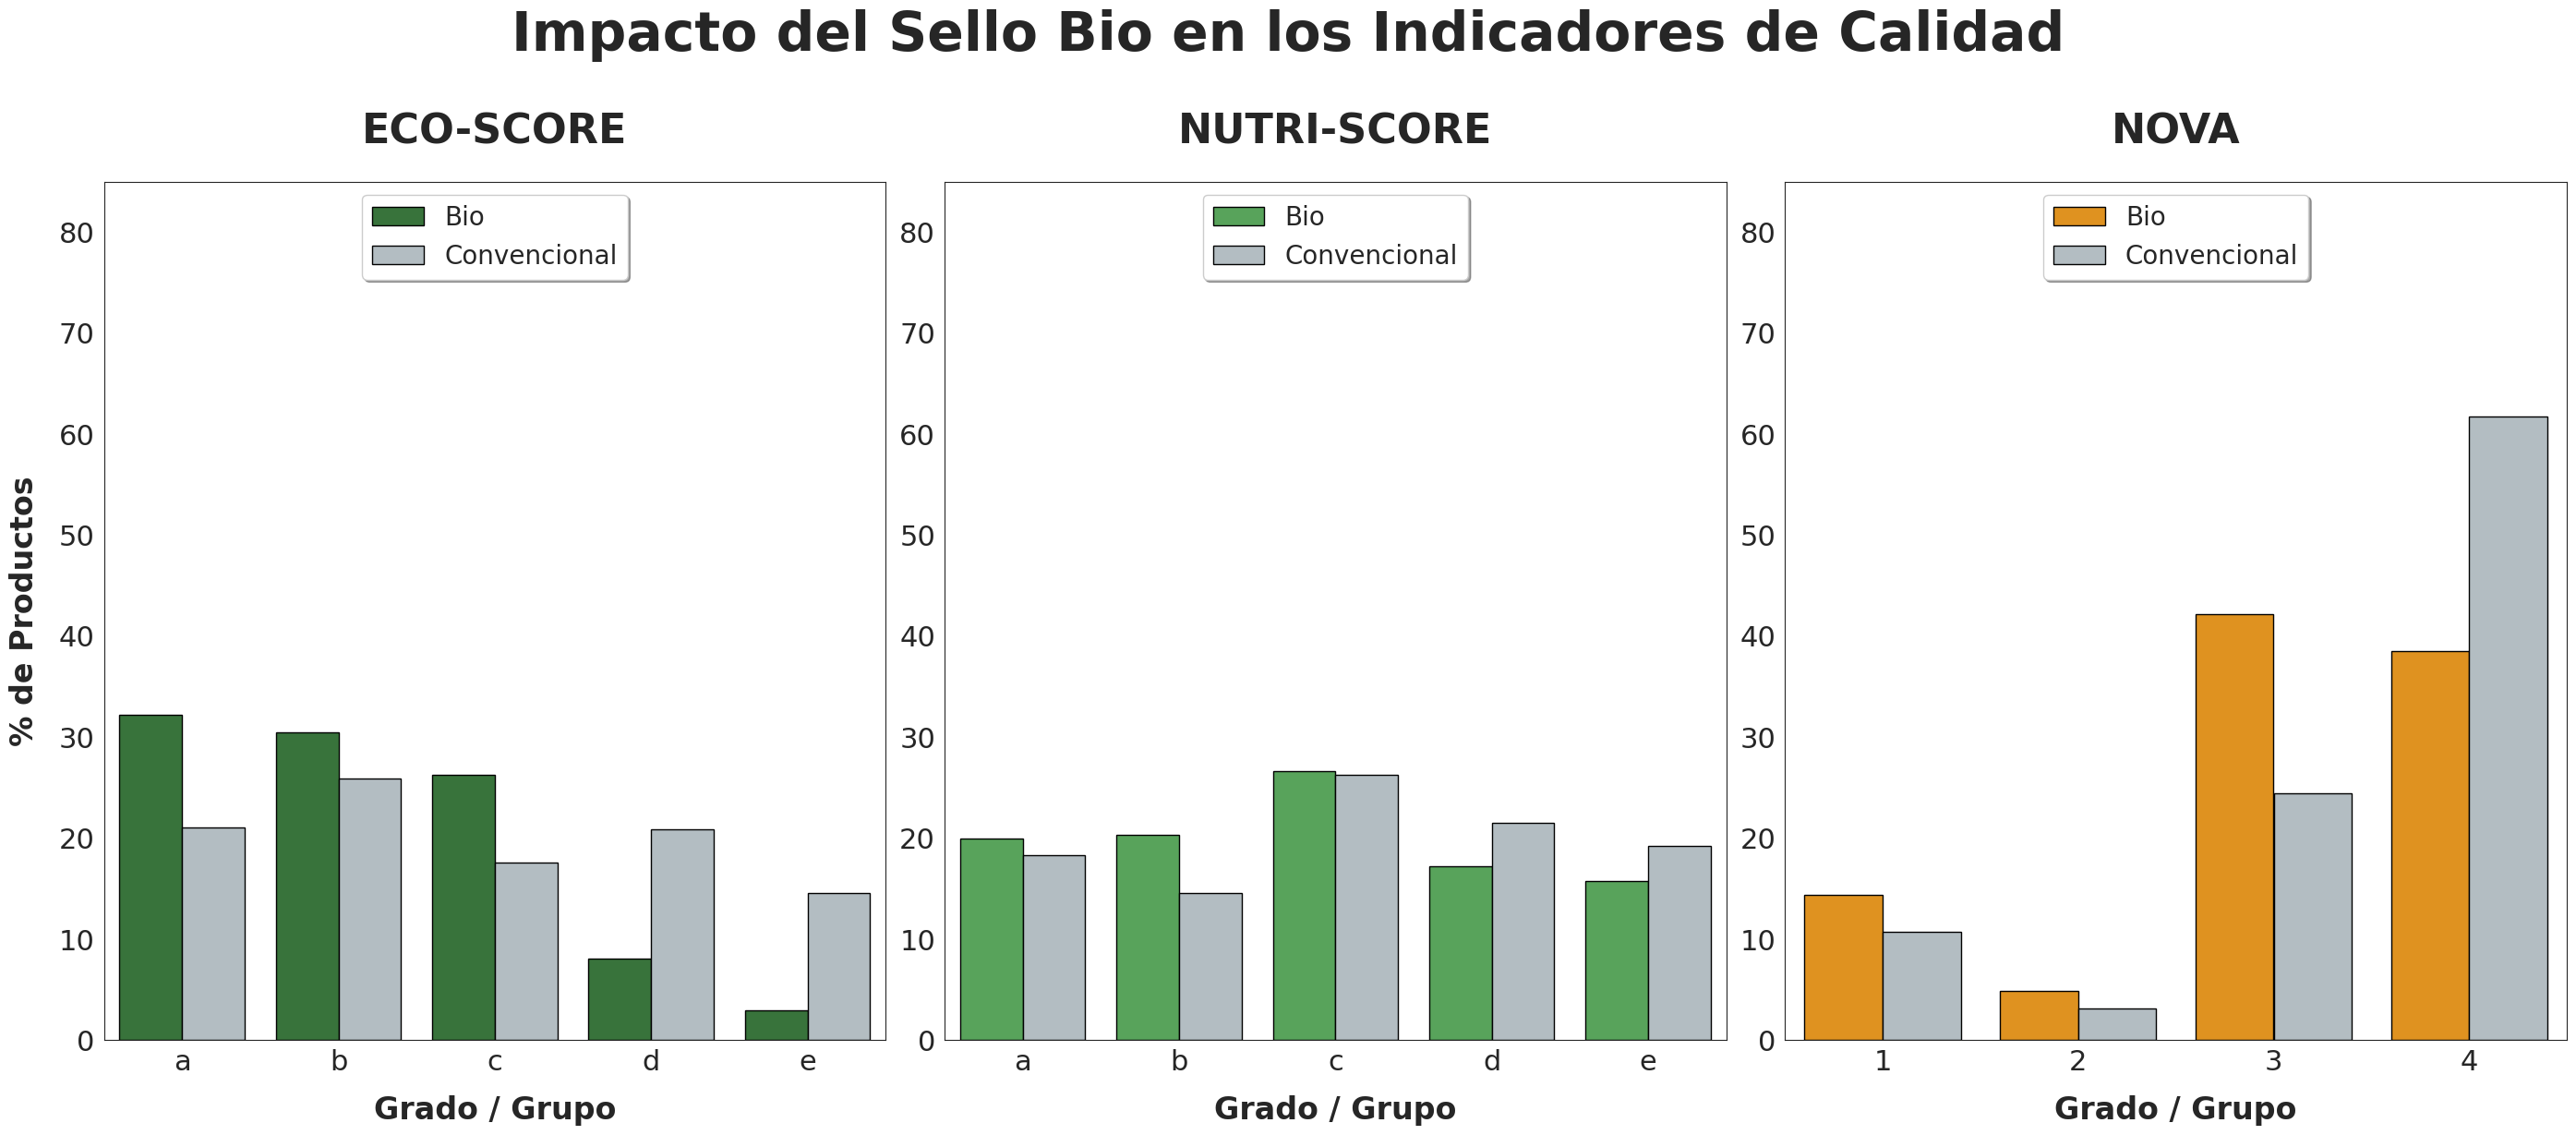

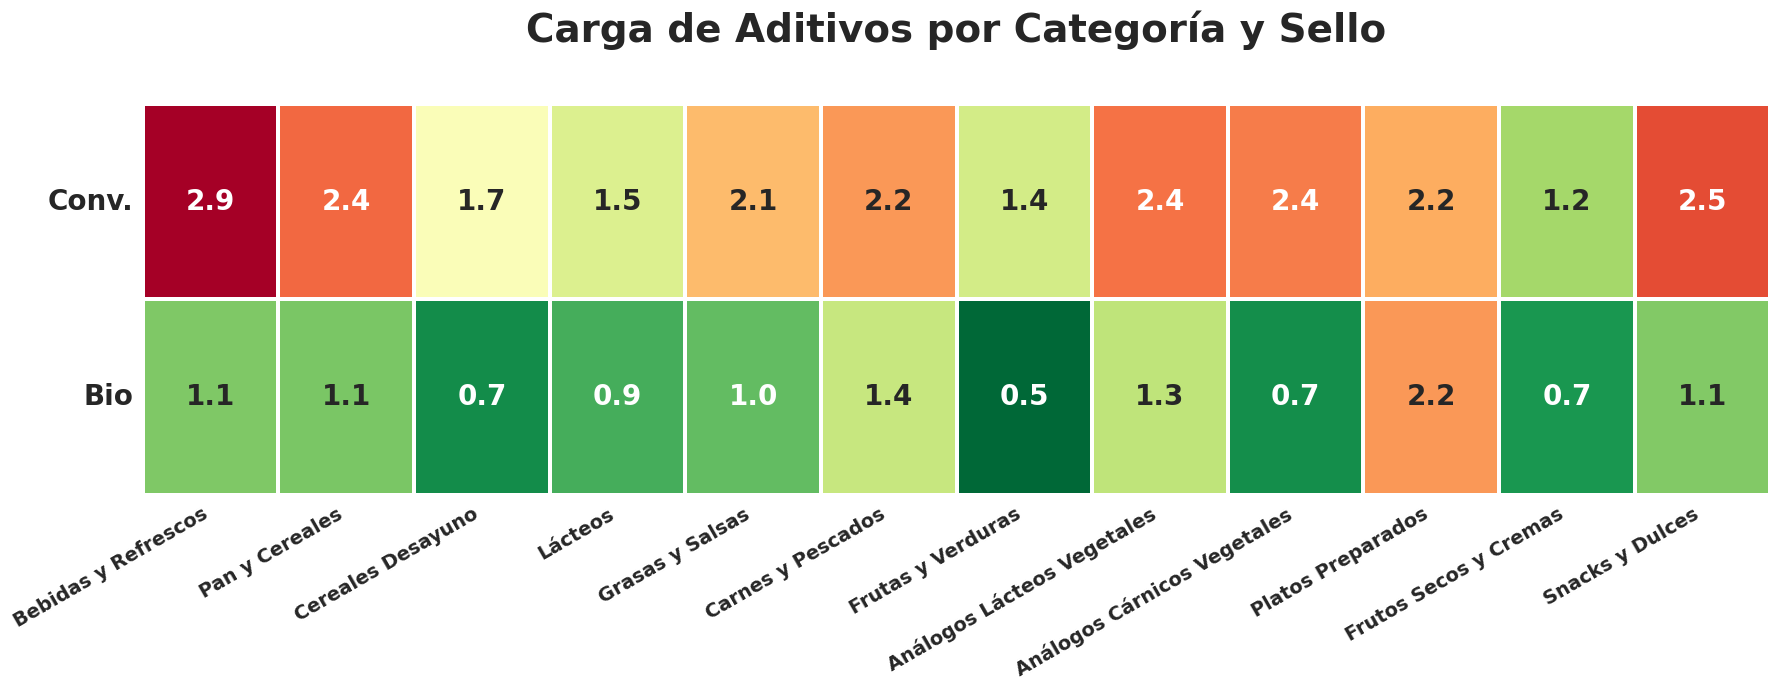

✅ Análisis H02 completado.


In [5]:
from utils.plots import pipeline_figuras_h02
pipeline_figuras_h02(df_audit)

## H03: Guerra de Fabricantes (Marcas Blancas vs. Multinacionales)

### Aquí enfrentamos la estrategia de formulación de las grandes corporaciones (Nestlé, Danone, Unilever, etc.) frente a las marcas blancas de los principales retailers (Mercadona, Lidl, Carrefour, Aldi). El objetivo es desmitificar quién ofrece un catálogo más saludable y sostenible.

### ¿Tienen las grandes multinacionales mejores perfiles nutricionales que las marcas blancas más económicas?

### Para responder a esto, ejecutamos tres niveles de análisis visual:

### Calidad del Catálogo: Comparativa de la distribución de Nutri-Score entre ambos grupos para medir la apuesta por la salud de cada modelo de negocio.

### Perfil Nutricional de Guerrilla: Análisis de las medianas de nutrientes críticos (azúcares, grasas saturadas, sal) para detectar diferencias reales en las recetas.

### Auditoría de Formulación: Evaluación de la presencia de aditivos y sostenibilidad (Eco-Score) para determinar quién prioriza la eficiencia de costes sobre la calidad.

📊 Iniciando Comparativa de Fabricantes (H03)...


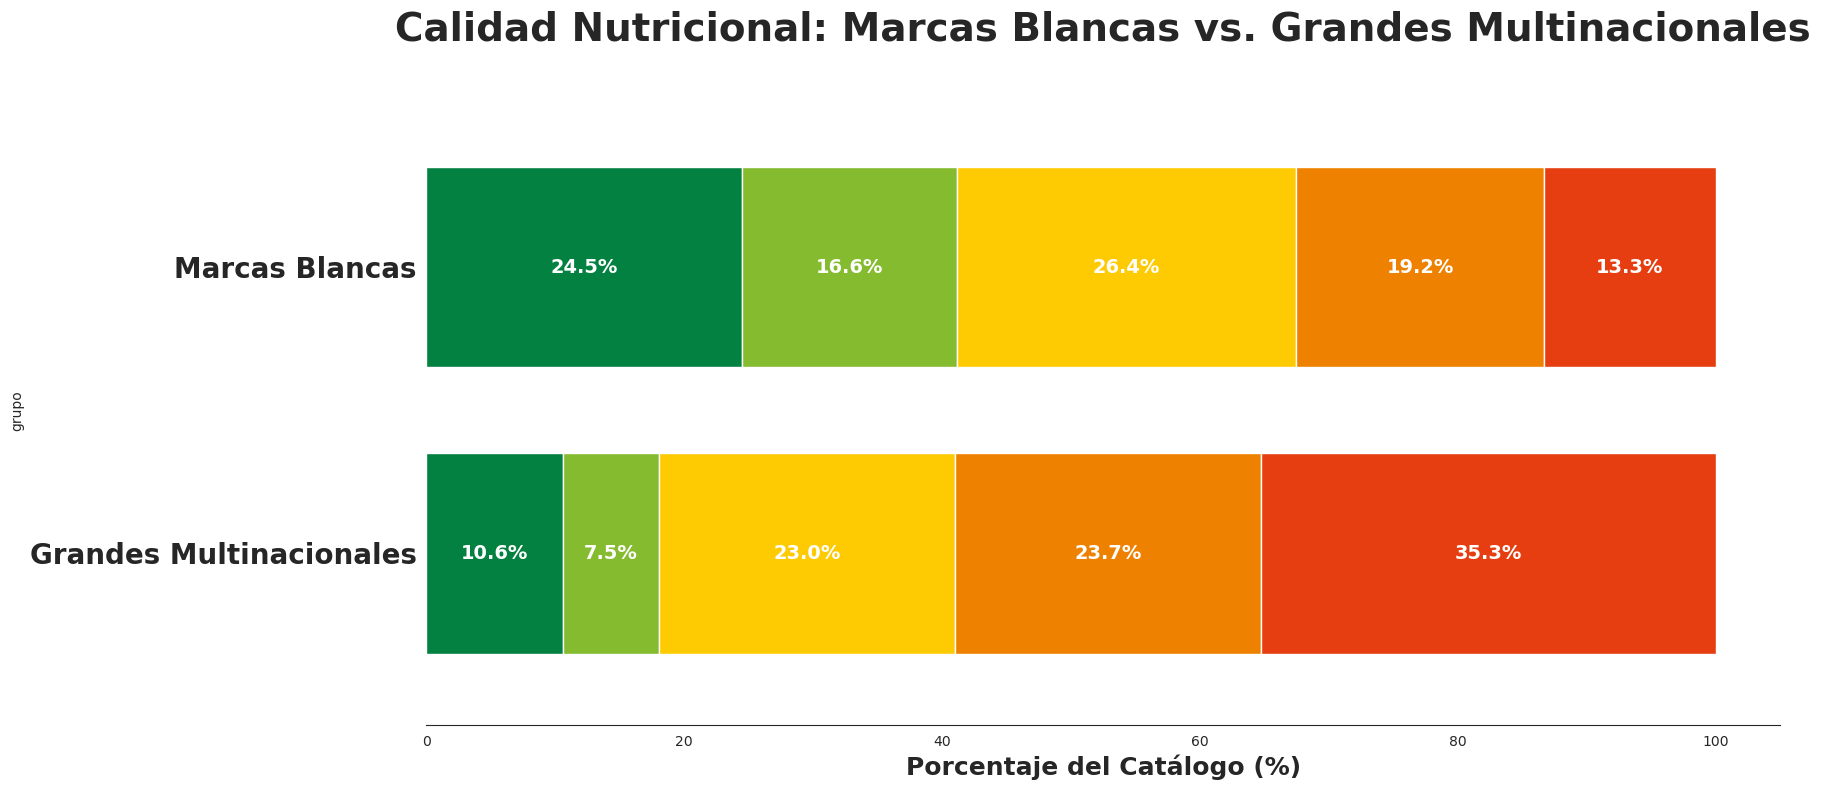

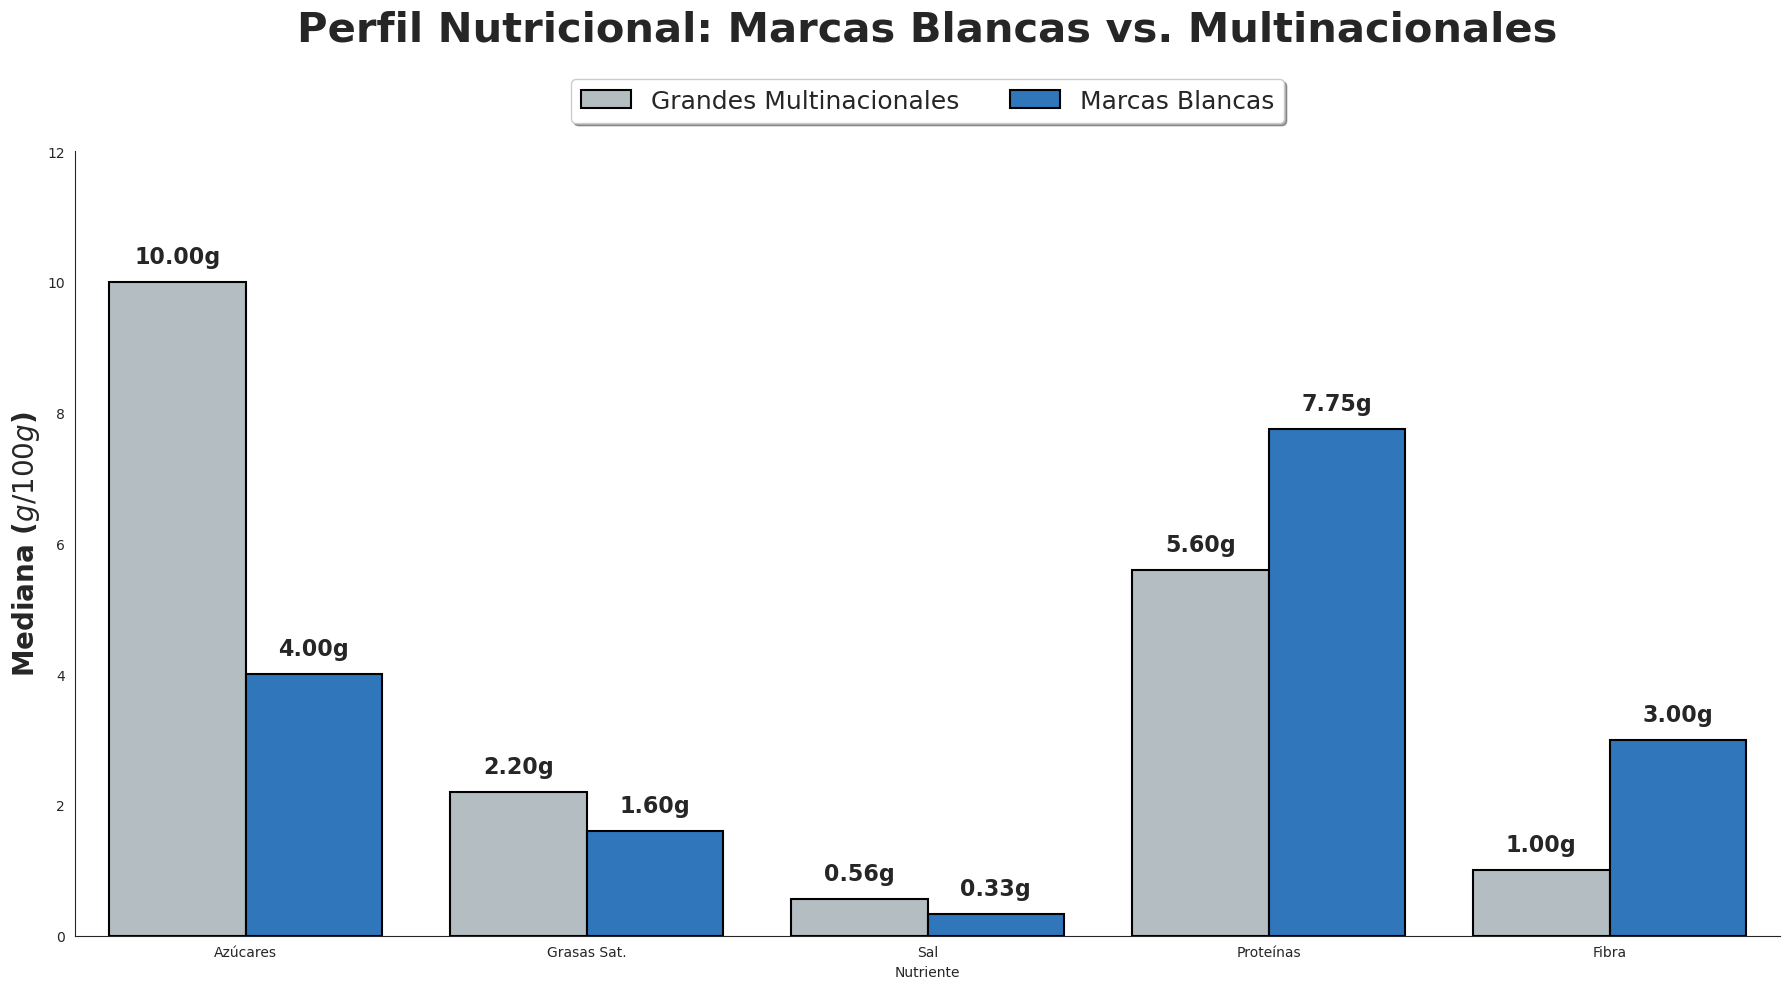

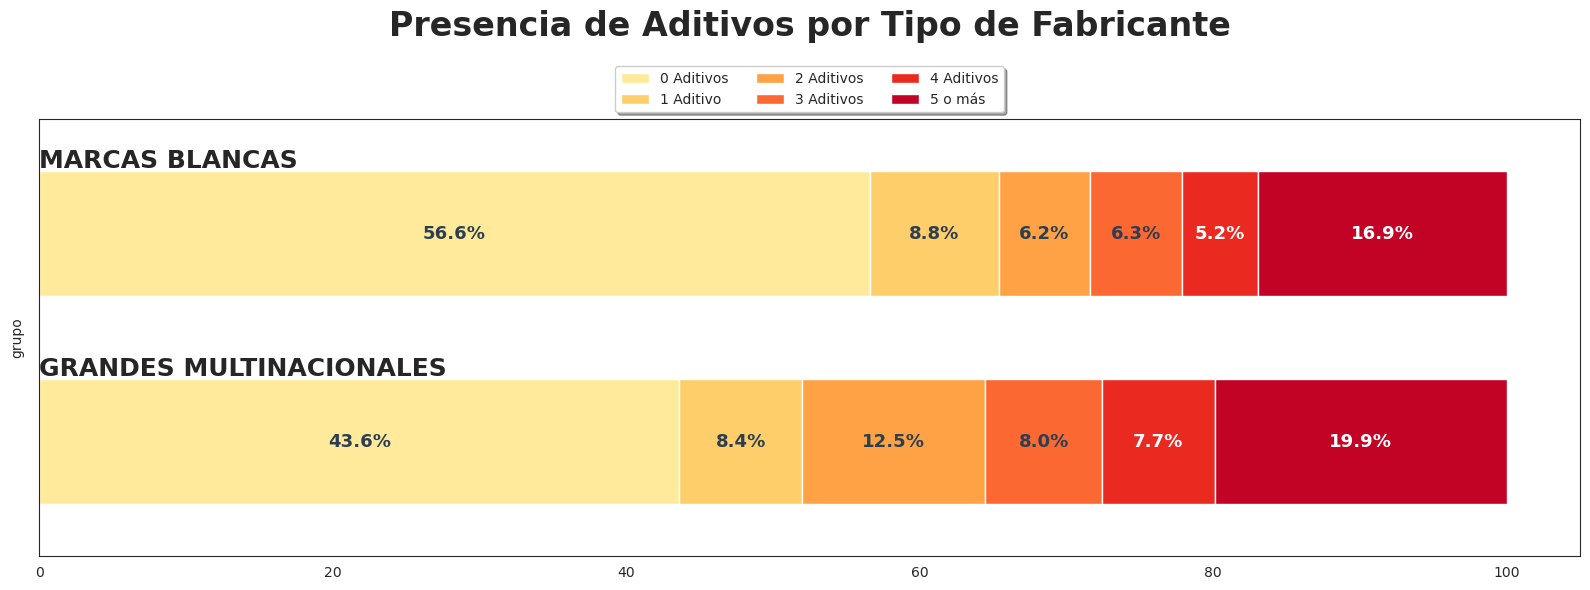

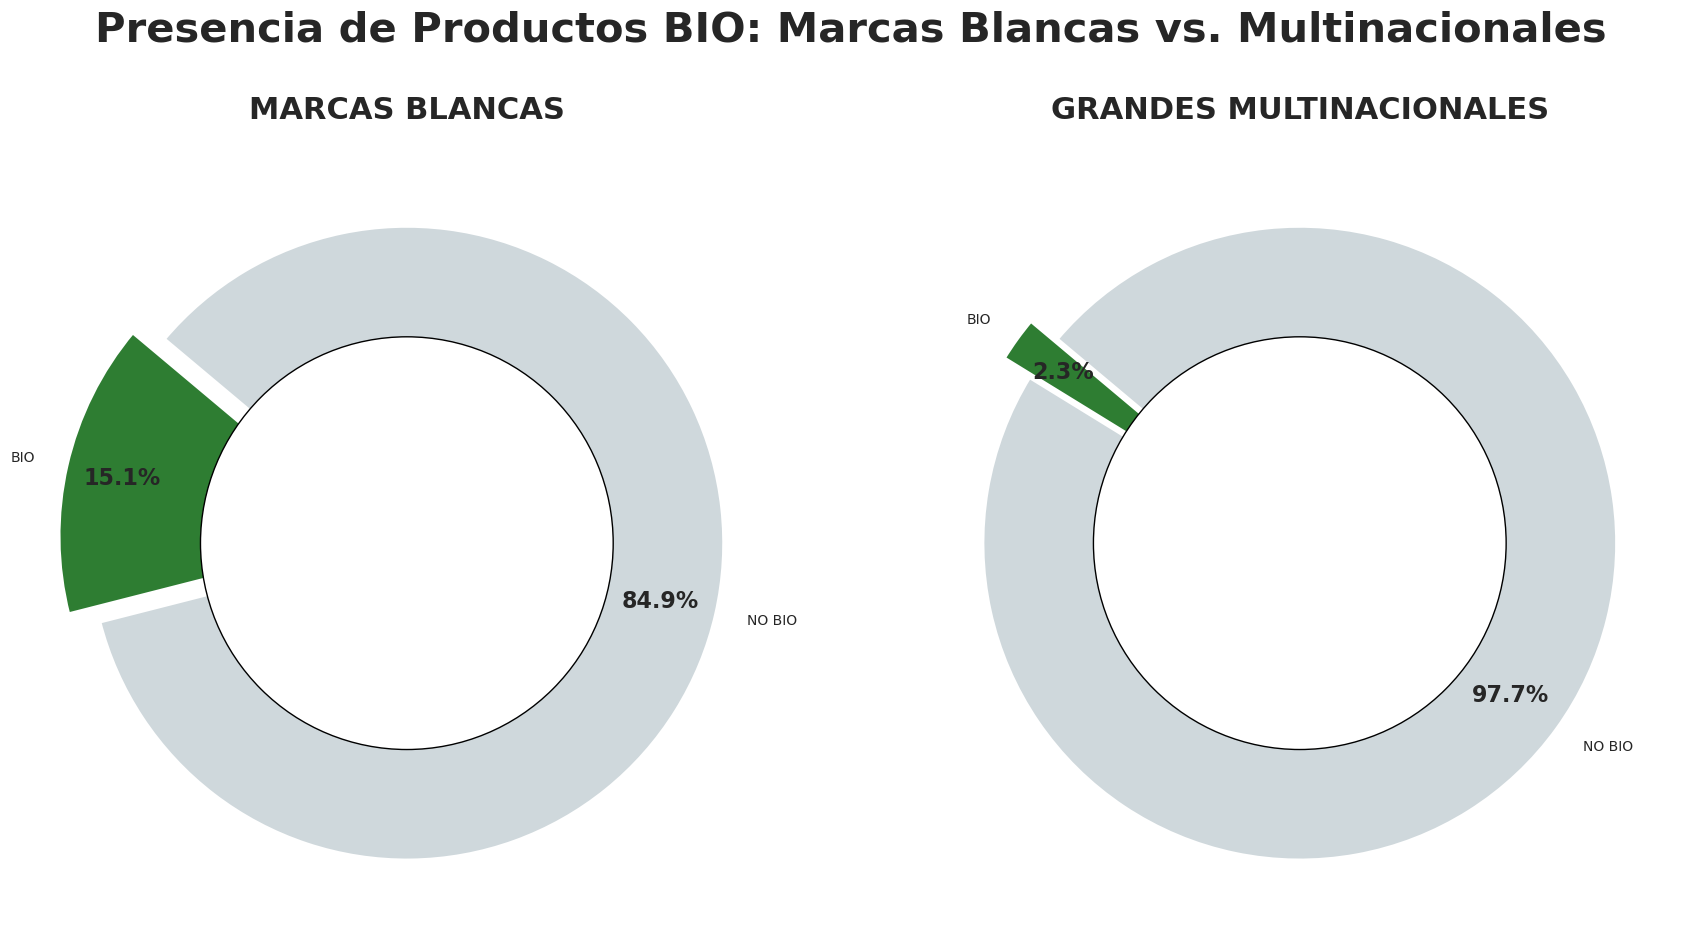

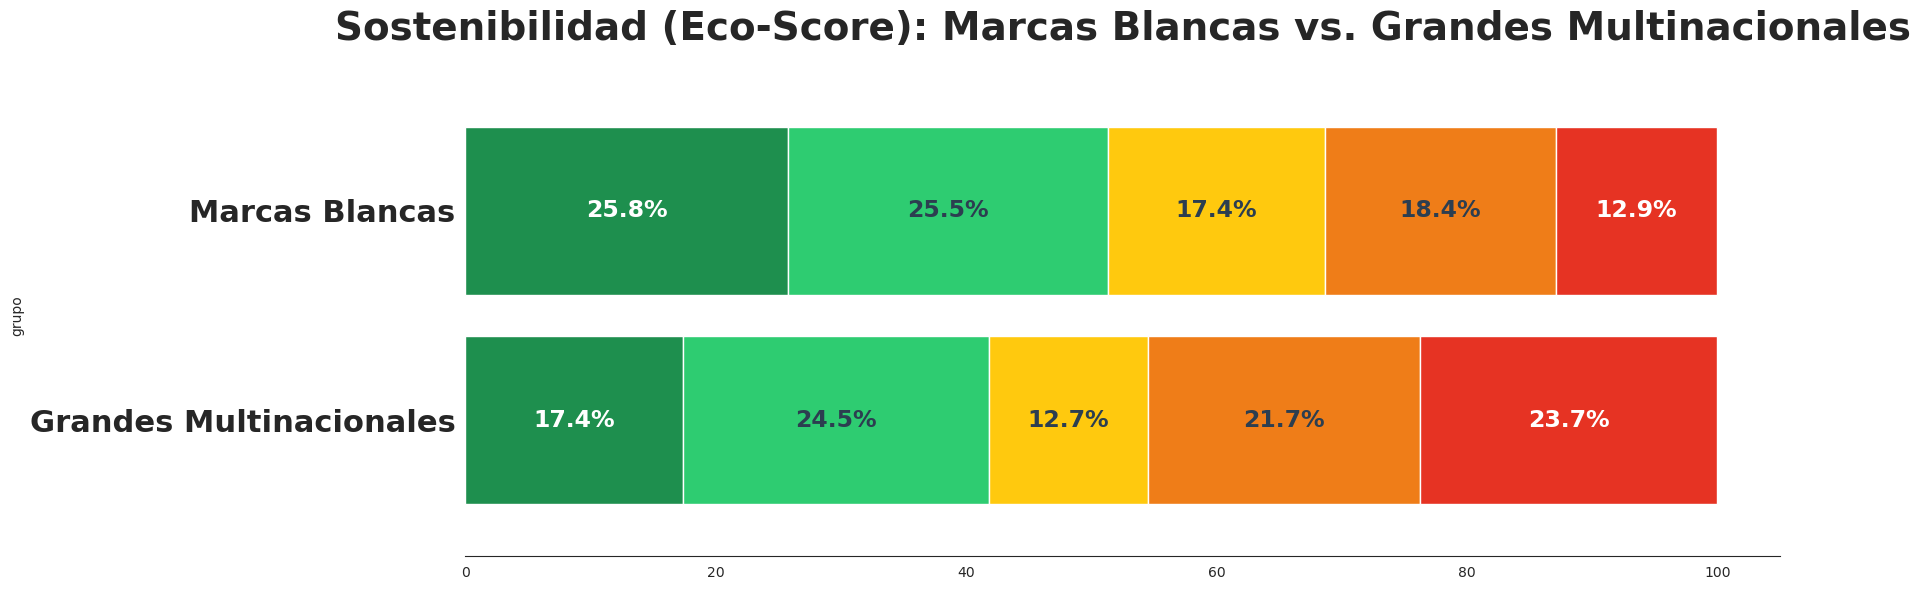

✅ Análisis H03 completado.


In [6]:
from utils.plots import pipeline_figuras_h03
pipeline_figuras_h03(df_audit)

## H04: Geopolítica Alimentaria (Cultura Cárnica vs. Transición Vegetal)

### En este bloque final cruzamos los datos de Open Food Facts con estadísticas de producción ganadera de la FAO. Analizamos cómo la tradición cárnica de un país influye en la calidad y penetración de sus alternativas vegetales (Plant-Based).

### ¿Son los países con mayor tradición ganadera los que producen análogos cárnicos más ultraprocesados?

### Para responder a esto, ejecutamos tres niveles de análisis visual:

### Análisis de Triple Eje: Correlación entre la producción de carne (FAO), la cuota de mercado de análogos vegetales y su complejidad química (mediana de aditivos).

### Densidad Proteica: Comparativa de la calidad nutricional de las proteínas vegetales frente al volumen de producción ganadera por país.

### Madurez del Mercado: Evaluación de cómo España, Alemania, Francia y Reino Unido gestionan el equilibrio entre su cultura tradicional y la nueva ingeniería alimentaria.

📊 Iniciando Análisis Estratégico Internacional (H04)...


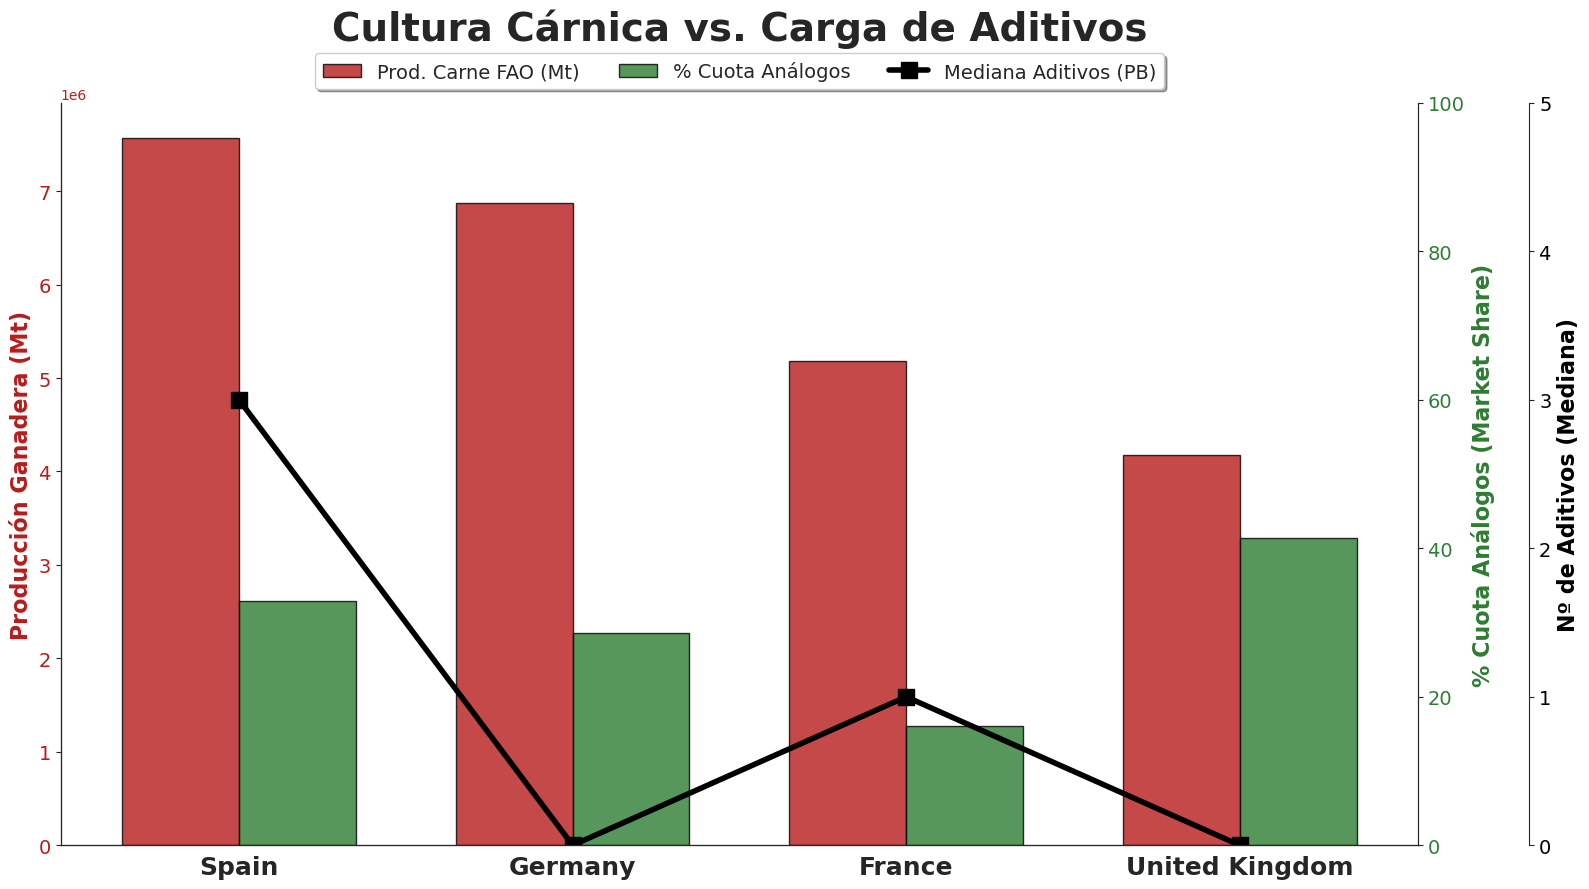

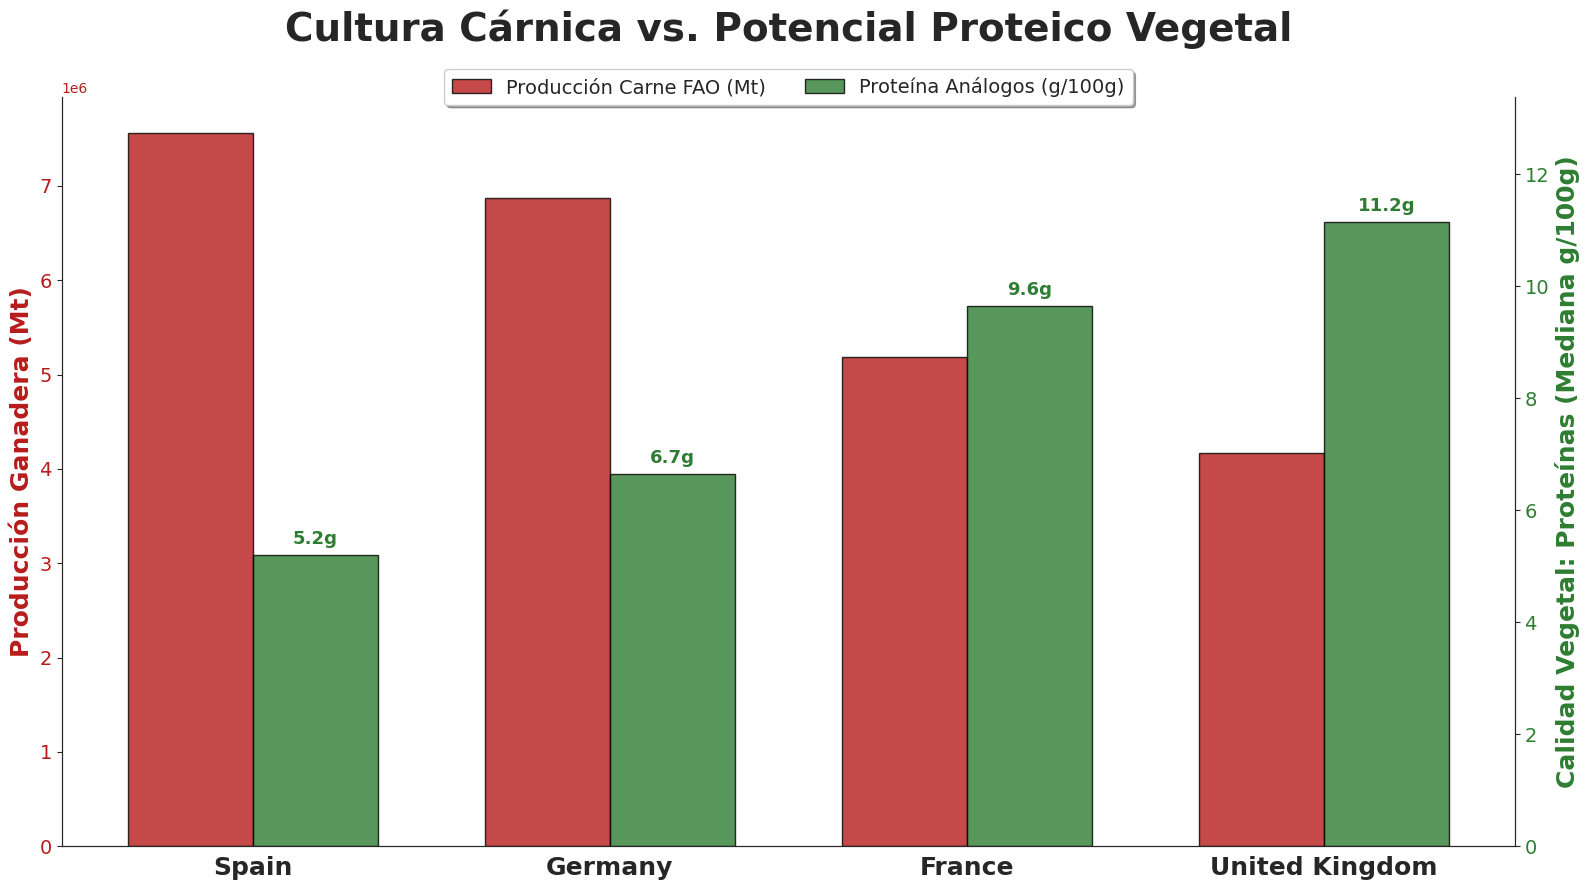

✅ Análisis H04 completado.


In [7]:
from utils.plots import pipeline_figuras_h04
pipeline_figuras_h04(df_audit, df_meat_production)